# Correlation Analysis of Student Dropout

This notebook explores how academic performance, engagement, and enrollment variables relate to student dropout. It prepares the cleaned dataset, calculates Pearson correlations, visualizes the results, and checks their statistical significance.

## 1. Setup

Install the libraries used for data handling and correlation visualizations. This cell only needs to be run if the packages are not already available.


In [2]:
%pip install -q pandas seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Analysis workflow

The analysis follows four short steps: load and inspect the data, prepare numeric variables, calculate correlations with dropout, and test whether the relationships are statistically significant.


## 2. Load the dataset

Reads the cleaned CSV file into a pandas DataFrame and previews its first five rows.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../Data/dropout_clean.csv"

df = pd.read_csv(file_path)
print(df[0:5])

   Dropout (1=Yes 0=No)  Study Mode  Entry Year  Displaced Student  \
0                     0           1      2021.0                  1   
1                     0           1      2022.0                  0   
2                     0           1      2020.0                  0   
3                     0           1      2022.0                  1   
4                     0           1      2019.0                  1   

   Overall Pass Rate (%)  Pass Rate Semester A (%)  Pass Rate Semester B (%)  \
0                 100.00                    100.00                    100.00   
1                   0.00                      0.00                      0.00   
2                  80.43                     86.96                     73.91   
3                  32.50                     58.33                     21.43   
4                  67.74                    100.00                     50.00   

   Pass Rate Last Year (%)  Credits Enrolled Total  Credits Passed Total  ...  \
0               1

### Check row indexing

Verifies whether every row in the DataFrame has a unique index value.


In [4]:
df.index.is_unique


True

## 3. Prepare variables

Inspect column types and identify identifiers, sparse variables, and category codes that should not be treated as continuous measurements.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20427 entries, 0 to 20426
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Dropout (1=Yes 0=No)          20427 non-null  int64  
 1   Study Mode                    20427 non-null  int64  
 2   Entry Year                    15306 non-null  float64
 3   Displaced Student             20427 non-null  int64  
 4   Overall Pass Rate (%)         19262 non-null  float64
 5   Pass Rate Semester A (%)      17284 non-null  float64
 6   Pass Rate Semester B (%)      19183 non-null  float64
 7   Pass Rate Last Year (%)       14551 non-null  float64
 8   Credits Enrolled Total        20427 non-null  float64
 9   Credits Passed Total          20427 non-null  float64
 10  Credits Passed Normal         20427 non-null  float64
 11  Credits Passed Sem A          20427 non-null  float64
 12  Credits Passed Sem B          20427 non-null  float64
 13  C

### Columns with limited usable data

The following fields contain many missing values and are excluded from this analysis: `Unpaid Fees Flag`, `Test Submissions (Total)`, `Assignment Submissions (Total)`, `Second Degree Student`, and `Pass Rate 2 Years Ago (%)`.


Removing sparse columns prevents them from producing mostly missing correlations. Identifier and categorical-code columns are also excluded because their numeric values do not represent meaningful continuous quantities.

### Select columns for correlation

Drop the student identifier, sparse fields, and selected category-code columns. These values could create misleading correlations because their numbers act as labels rather than measured quantities.

In [6]:
columns_to_drop = []
df = df.drop(columns=columns_to_drop)
print(df)


       Dropout (1=Yes 0=No)  Study Mode  Entry Year  Displaced Student  \
0                         0           1      2021.0                  1   
1                         0           1      2022.0                  0   
2                         0           1      2020.0                  0   
3                         0           1      2022.0                  1   
4                         0           1      2019.0                  1   
...                     ...         ...         ...                ...   
20422                     0           1         NaN                  1   
20423                     1           1      2022.0                  0   
20424                     0           1      2019.0                  0   
20425                     0           1      2021.0                  0   
20426                     0           1      2020.0                  0   

       Overall Pass Rate (%)  Pass Rate Semester A (%)  \
0                     100.00                    100.0

### Convert values to numeric data

Replaces decimal commas with decimal points and converts every remaining column to a numeric type.


In [7]:
df = df.replace(",", ".", regex=True)
df = df.apply(pd.to_numeric)

### Drop NANs and Review the prepared dataset

Drop NANs and Displays the prepared DataFrame before calculating correlations.


In [8]:
df = pd.DataFrame.dropna(df)

print(df)

       Dropout (1=Yes 0=No)  Study Mode  Entry Year  Displaced Student  \
2                         0           1      2020.0                  0   
4                         0           1      2019.0                  1   
5                         0           1      2019.0                  0   
6                         0           1      2020.0                  1   
7                         0           1      2019.0                  1   
...                     ...         ...         ...                ...   
20413                     0           1      2020.0                  1   
20416                     0           1      2021.0                  1   
20424                     0           1      2019.0                  0   
20425                     0           1      2021.0                  0   
20426                     0           1      2020.0                  0   

       Overall Pass Rate (%)  Pass Rate Semester A (%)  \
2                      80.43                     86.9

## 4. Calculate correlations

Calculate Pearson correlations for all numeric variables, then extract the correlations with the dropout indicator. Values near +1 show a strong positive relationship, values near -1 a strong negative relationship, and values near 0 little linear relationship.


In [9]:
corr_matrix = df.corr()
corr_vector = df.corr()["Dropout (1=Yes 0=No)"]

print(corr_vector)


Dropout (1=Yes 0=No)            1.000000
Study Mode                     -0.094189
Entry Year                      0.015016
Displaced Student              -0.016038
Overall Pass Rate (%)          -0.245161
Pass Rate Semester A (%)       -0.168230
Pass Rate Semester B (%)       -0.239598
Pass Rate Last Year (%)        -0.130684
Credits Enrolled Total         -0.053680
Credits Passed Total           -0.216532
Credits Passed Normal          -0.224758
Credits Passed Sem A           -0.132249
Credits Passed Sem B           -0.161991
Credits Pending Grade           0.007442
Lowest Year of Study           -0.104557
Highest Year of Study          -0.096134
Platform Days Logged (Total)   -0.096320
Platform Events (Total)        -0.058414
Platform Minutes (Total)       -0.093116
Platform Visits (Total)        -0.090761
Campus WiFi Days (Total)       -0.097127
Resource Access Days (Total)   -0.091777
Performance Bucket             -0.225935
Engagement Level               -0.093599
Credits Enrolled

## 5. Visualize the full correlation matrix

Display all pairwise correlations in a heatmap. Red and blue show opposite relationship directions, while stronger color intensity indicates a larger absolute correlation.


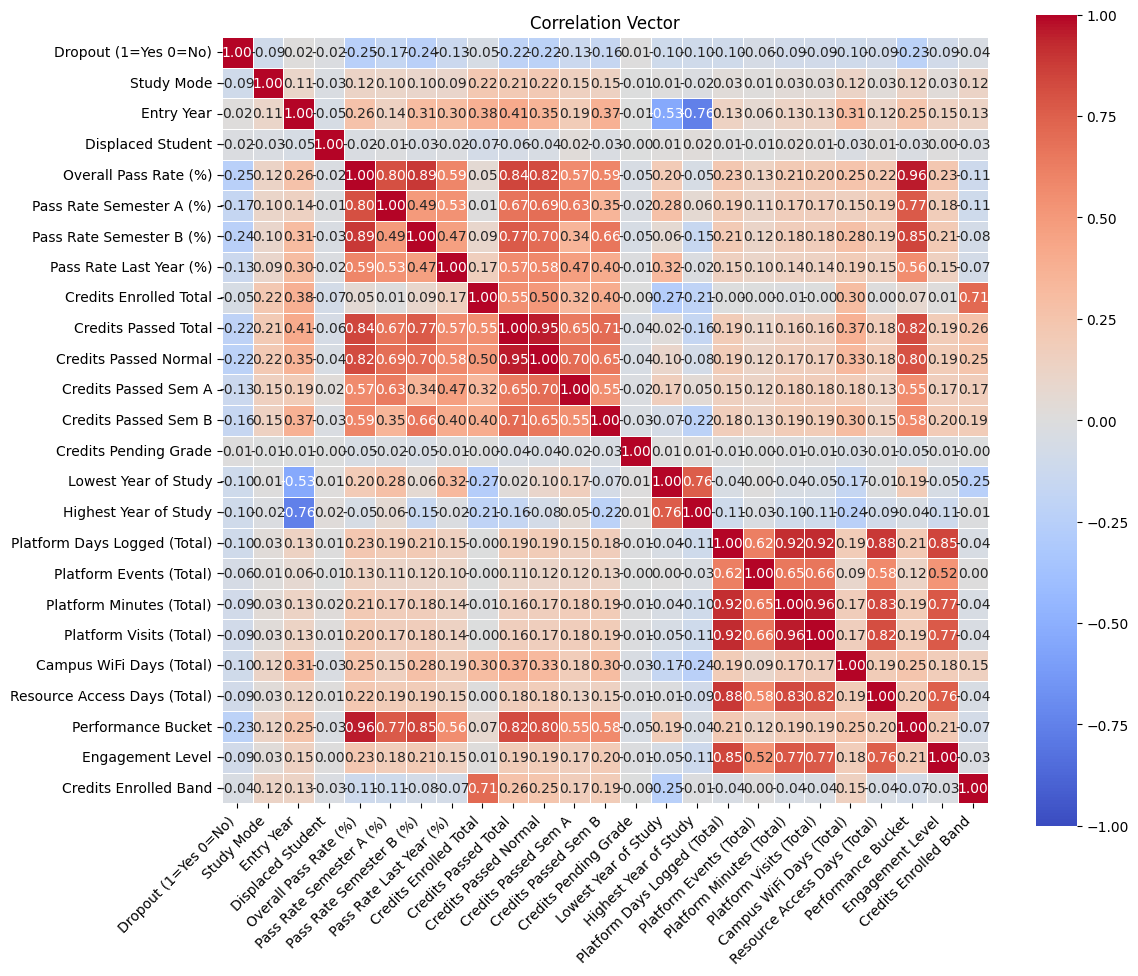

In [10]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Vector")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Focus on correlations with dropout

Sort the dropout correlations by absolute value so the strongest positive or negative relationships appear first. This ranking shows association, not causation.


The target variable itself appears first with a correlation of 1.00 and should be ignored when interpreting predictors.

In [11]:
corr_vector = corr_vector.sort_values(key=abs, ascending=False)
reference_col = "Dropout (1=Yes 0=No) "
correlation_df = corr_vector.to_frame(name=f"Correlation with '{reference_col}'")
print(correlation_df)

                              Correlation with 'Dropout (1=Yes 0=No) '
Dropout (1=Yes 0=No)                                          1.000000
Overall Pass Rate (%)                                        -0.245161
Pass Rate Semester B (%)                                     -0.239598
Performance Bucket                                           -0.225935
Credits Passed Normal                                        -0.224758
Credits Passed Total                                         -0.216532
Pass Rate Semester A (%)                                     -0.168230
Credits Passed Sem B                                         -0.161991
Credits Passed Sem A                                         -0.132249
Pass Rate Last Year (%)                                      -0.130684
Lowest Year of Study                                         -0.104557
Campus WiFi Days (Total)                                     -0.097127
Platform Days Logged (Total)                                 -0.096320
Highes

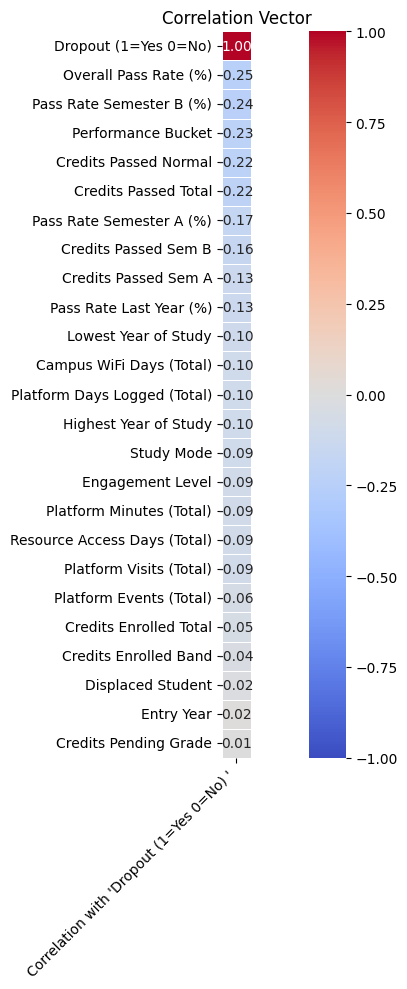

In [12]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Vector")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Check statistical significance

Calculate a Pearson p-value for each relationship with dropout. Stars mark conventional significance levels: `*` p ≤ 0.05, `**` p ≤ 0.01, and `***` p ≤ 0.001. Statistical significance does not necessarily mean the relationship is practically important.

In [13]:
import numpy as np
from scipy.stats import pearsonr
pval = df.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*corr_matrix.shape)
p = pval.map(lambda x: ''.join(['*' for t in [.05, .01, .001] if x<=t]))
(corr_matrix.round(2).astype(str)['Dropout (1=Yes 0=No)'] + p['Dropout (1=Yes 0=No)'])

Dropout (1=Yes 0=No)              1.0***
Study Mode                      -0.09***
Entry Year                          0.02
Displaced Student                  -0.02
Overall Pass Rate (%)           -0.25***
Pass Rate Semester A (%)        -0.17***
Pass Rate Semester B (%)        -0.24***
Pass Rate Last Year (%)         -0.13***
Credits Enrolled Total          -0.05***
Credits Passed Total            -0.22***
Credits Passed Normal           -0.22***
Credits Passed Sem A            -0.13***
Credits Passed Sem B            -0.16***
Credits Pending Grade               0.01
Lowest Year of Study             -0.1***
Highest Year of Study            -0.1***
Platform Days Logged (Total)     -0.1***
Platform Events (Total)         -0.06***
Platform Minutes (Total)        -0.09***
Platform Visits (Total)         -0.09***
Campus WiFi Days (Total)         -0.1***
Resource Access Days (Total)    -0.09***
Performance Bucket              -0.23***
Engagement Level                -0.09***
Credits Enrolled

## 7. Further feature visualizations

This section can be used to examine the strongest relationships in more detail with plots such as box plots, histograms, or grouped dropout rates.